# Random Forest Hyperparameter Optimization

The Random Forest classifier achieved the best overall performance in the previous model comparison.

The objective of this notebook is to investigate whether systematic hyperparameter tuning can further improve fraud detection performance.

Model performance is evaluated using the F1-Score, as it provides a balanced measure of Precision and Recall for highly imbalanced classification problems.

In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import(train_test_split, RandomizedSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, precision_score, recall_score, f1_score)

# Daten laden
RANDOM_STATE = 42
# Datensatz herunterladen
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_file = Path(path) / "creditcard.csv"
df = pd.read_csv(csv_file)
df = df.drop_duplicates()

# Featrues und Target
X = df.drop("Class", axis=1)
y = df["Class"]

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(y.value_counts())


#Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# Baseline Random Forest
baseline_rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
baseline_rf.fit(X_train, y_train)
baseline_pred = baseline_rf.predict(X_test)
baseline_prob = baseline_rf.predict_proba(X_test)[:,1]
baseline_f1 = f1_score(y_test, baseline_pred)
baseline_roc_auc = roc_auc_score(y_test, baseline_prob)
print(f"Baseline F1: {baseline_f1:.4f}")

baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
print(f"Baseline Precision: {baseline_precision:.4f}")
print(f"Baseline Recall: {baseline_recall:.4f}")
print(f"Baseline F1: {baseline_f1:.4f}")
print(f"Baseline Roc-AUC: {baseline_roc_auc:.4f}")

Dataset shape: (283726, 31)

Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64
Baseline F1: 0.8263
Baseline Precision: 0.9583
Baseline Recall: 0.7263
Baseline F1: 0.8263
Baseline Roc-AUC: 0.9474


## Hyperparameter Search Space

The following Random Forest parameters are optimized using RandomizedSearchCV.

The objective is to maximize the F1-Score on cross-validation folds.

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40}
n_estimators: 100
min_samples_split: 2
min_samples_leaf: 1
max_features: log2
max_depth: 40

Best CV F1:
0.8598649701913033
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.74      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746

Precision: 0.9589
Recall: 0.7368
F1: 0.8333
ROC-AUC: 0.9338

Baseline vs Tuned Model


,Metric,Baseline,Tuned
0,Precision,0.958333,0.958904
1,Recall,0.726316,0.736842
2,F1,0.826347,0.833333
3,ROC-AUC,0.947420,0.933846


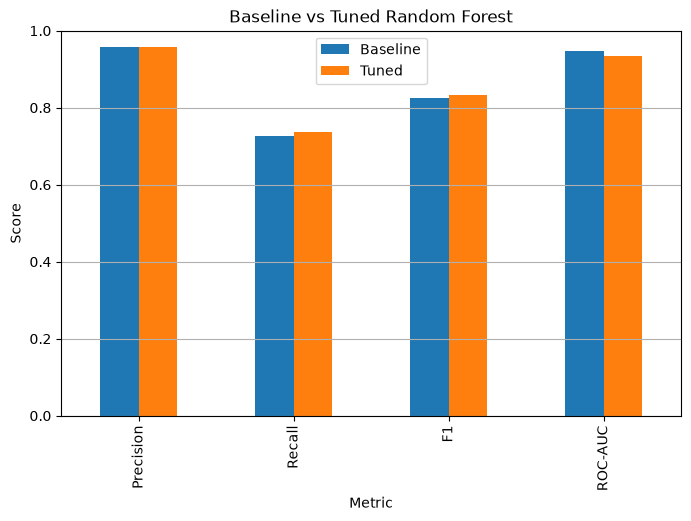

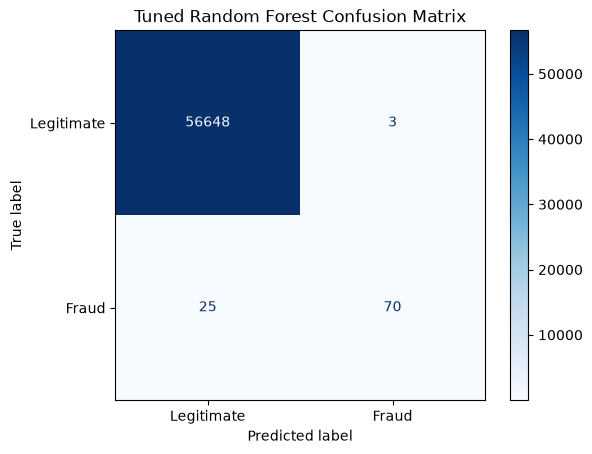

In [3]:
# Hyperparameter Grid
param_grid = {"n_estimators": [100, 200, 300, 500], "max_depth": [None, 10, 20, 30, 40],
              "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4], "max_features": ["sqrt", "log2"]}

# RandomizedSearchCV
rf = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, n_iter= 25,
                                   scoring="f1", cv=5, verbose=2, random_state=RANDOM_STATE, n_jobs=-1)
random_search.fit(X_train, y_train)

# Beste Parameter
print("Best Parameters:")
print(random_search.best_params_)
best_params = random_search.best_params_
for key, value in best_params.items():
    print(f"{key}: {value}")
print("\nBest CV F1:")
print(random_search.best_score_)

# Bestes Modell evaluieren
best_rf  = random_search.best_estimator_
y_pred = best_rf.predict(X_test)
print(classification_report(y_test, y_pred))

# Kennzahlen
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
y_prob = best_rf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

comparison = pd.DataFrame({"Metric": ["Precision", "Recall", "F1", "ROC-AUC"], "Baseline": [baseline_precision, baseline_recall, baseline_f1, baseline_roc_auc],
                           "Tuned": [precision, recall, f1, roc_auc]})

print("\nBaseline vs Tuned Model")
display(comparison)

comparison.set_index("Metric").plot(kind="bar", figsize=(8,5))
plt.title("Baseline vs Tuned Random Forest")
plt.ylabel("Score")
plt.ylim(0,1)
plt.grid(axis="y")
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
disp.plot(cmap="Blues")
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

## Key Findings

Hyperparameter optimization improved the performance of the Random Forest classifier when optimizing for F1-Score.

Compared to the baseline model:

- Precision improved slightly from 0.9583 to 0.9589
- Recall increased from 0.7263 to 0.7368
- F1-Score improved from 0.8263 to 0.8333
- ROC-AUC decreased from 0.9474 to 0.9338

The tuned model maintained an extremely low number of false positives (3) while detecting more fraudulent transactions than the baseline model.

An important observation is that optimizing for F1-Score improved Recall and overall class balance, but did not improve ROC-AUC. This highlights that model performance depends strongly on the selected optimization objective.

When comparing the results with the previous threshold optimization study, threshold selection had an even greater impact on business-relevant metrics than hyperparameter tuning.

This demonstrates that both hyperparameter optimization and threshold selection are important steps in fraud detection, but threshold selection may have the strongest influence on practical business outcomes.